**PYSPARK**

**what is pyspark:**
  * PySpark is the Python API for Apache Spark. It allows you to interface with Spark's distributed computation framework using Python. By using PySpark, you can create and manage Spark jobs, and perform complex data transformations and analyses. It acts like a bridge between Spark and Python.
  * Imagine you have a massive amount of data that you need to process. You can't do it on your computer alone because it would take too long.By using pyspark ,processing large datasets by distributing them across many computers to making it much faster.



**What is spark:**

* Apache Spark is a fast and general-purpose distributed computing system for large-scale data processing. It provides an engine for parallel data processing across a cluster of computers, allowing you to analyze massive datasets much faster than traditional single-machine approaches. Spark also offers high-level APIs in languages like Python (PySpark), Java, Scala, and R, making it easier to develop parallel applications.
* spark is primarly written in scala programming language.
* **Example**: Imagine you have a massive warehouse filled with products that need to be processed (like sorted, counted, or analyzed).

  * **Without Spark:** You would have a small team trying to process all the products in the warehouse by themselves. This would be slow and inefficient because the team would be overwhelmed by the sheer volume of items.

  * **With Spark:** You have a large team of workers, and the warehouse is divided into sections. Each worker is responsible for processing the items in their assigned section, all at the same time. Once each section is processed, the results are combined to give you the overall result. This allows you to handle the massive warehouse inventory quickly and efficiently.

**Why we use spark instead of pandas:**
  * Imagine you have a massive spreadsheet (like an Excel file or CSV) with billions of rows of data.

    * **Pandas** : is like trying to open and work with that entire spreadsheet on your personal computer. If the spreadsheet is too large, your computer might become very slow, or it might even crash because it can't handle that much data in its memory.

    * **PySpark** is like having a team of computers working together to analyze the same giant spreadsheet. PySpark splits the spreadsheet into smaller pieces and distributes those pieces to multiple computers. Each computer works on its piece of the data at the same time and sends back the result. Then, PySpark combines the results from all of the computers. This makes analyzing the huge spreadsheet much faster and more efficient than doing it on a single computer.

**Role of PySpark:**

  * In the current scenario, data-oriented processes are commonly done using Python. Spark itself is primarily written in Scala, which doesn't directly understand Python. This is where PySpark plays a crucial role. PySpark acts as a bridge, taking Python requests and sending them to Spark in a way that Spark (which understands Scala) can process. Once Spark processes the request, it sends the response back in Scala, and PySpark translates that response back into Python
  * It is done with the help of py4j
  * It act like a translator , it takes the pyspark code in python and translate them into the format of spark understand
  * And give the spark response in a way that python can use

**Reading files using pyspark:**
  * Apache Spark, by default, supports a rich set of APIs to read and write several file formats.

    * Text Files (.txt)
    * CSV Files (.csv)
    * TSV Files (.tsv)
    * Avro Files (.avro)
    * JSON Files (.json)
    * Parquet (.parquet)
    * ORC Files (.orc)
    * XML Files and many other formats

In [ ]:
pip install pyspark

In [2]:
from pyspark.sql import SparkSession


spark = SparkSession.builder.appName("ReadCSV").getOrCreate()


df = spark.read.csv("/content/pandas_sample.csv",header =True,inferSchema = True)  # header =true takes 1st row as col header
                                                                                   # inferSchema is used to automaticaaly choose the datatype otherwise all col denoted as str

df.show()
df.printSchema()
pandas = df.toPandas()
print(type(pandas))

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/content/pandas_sample.csv.

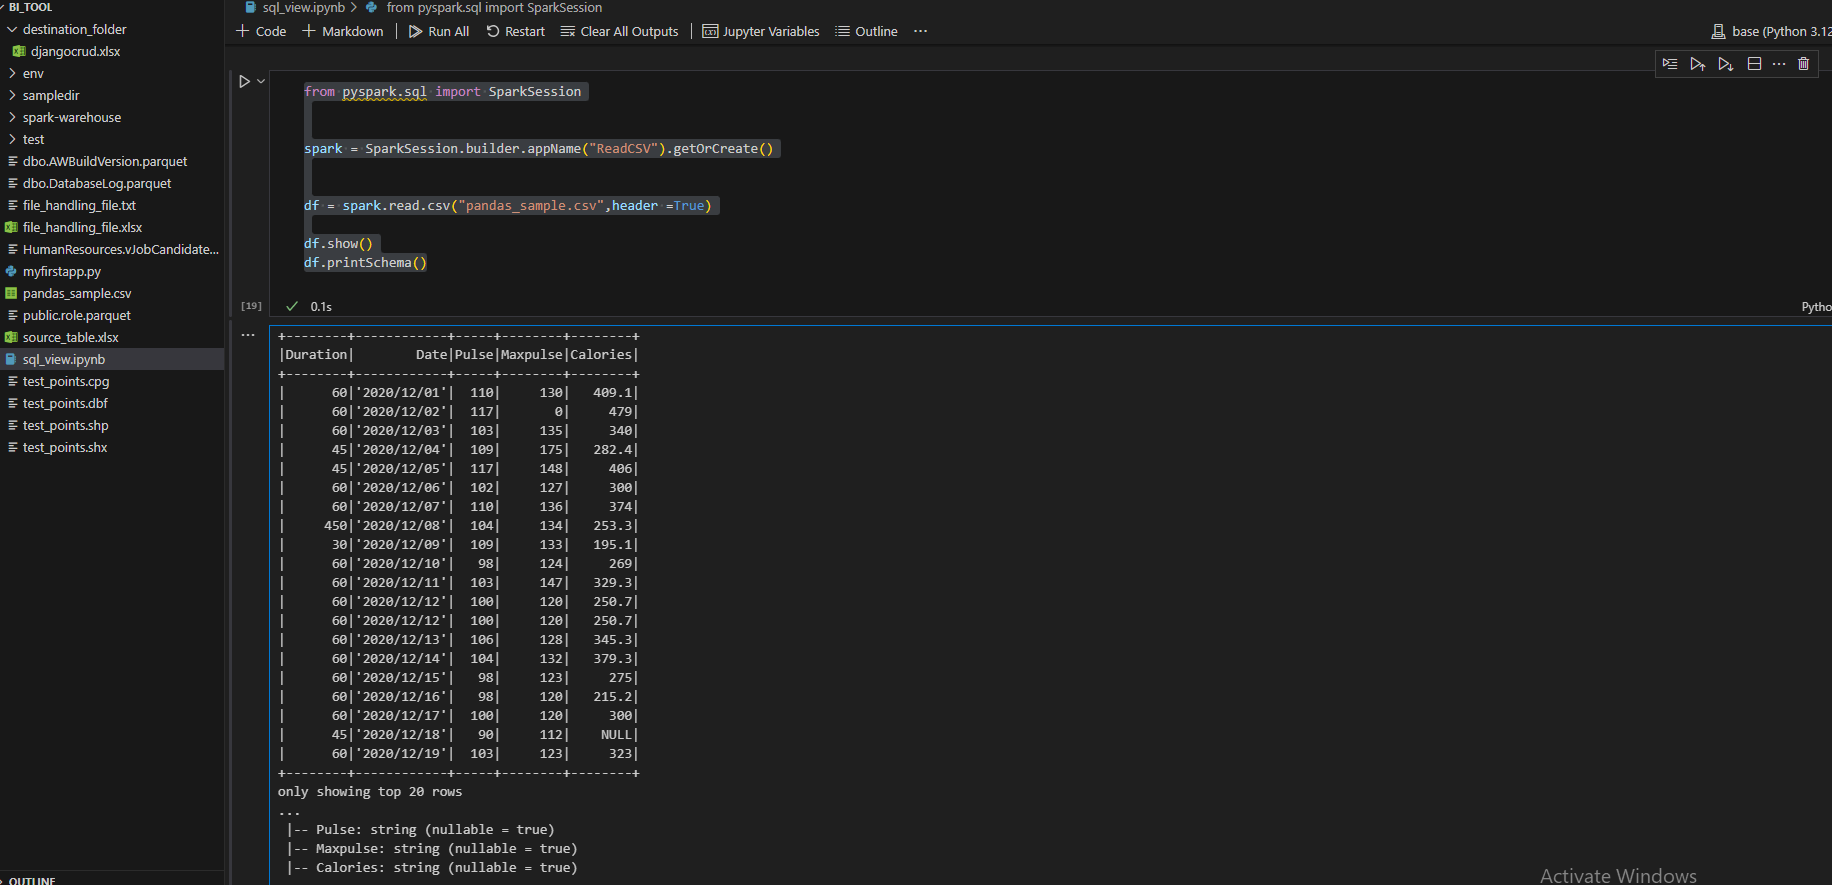

**Reading excel file in pyspark:**
* PySpark does not natively support reading Excel files in the same simple way as CSV files. While reading CSV files in PySpark is straightforward (using spark.read.csv()), Excel files require an additional external library like spark-excel to read them.
  * CSV files: These are simple text files with data separated by commas (or other delimiters), and Spark has built-in support to handle these files directly via spark.read.csv().

  *  Excel files: These are binary files that contain structured data in a table format with additional metadata (like sheets, rows, columns, styles, etc.). Spark doesn't natively understand how to process these files without additional help from external libraries like spark-excel.

In [ ]:
pip install spark-excel

In [ ]:
from pyspark.sql import SparkSession

# Create a Spark session with the spark-excel package
spark = SparkSession.builder \
    .appName("ExcelReadExample") \
    .config("spark.jars.packages", "com.crealytics:spark-excel_2.12:0.13.2") \
    .getOrCreate()

# Now you can read the Excel file using spark-excel
excel_file_path = "/content/System details.xlsx"

# Read the Excel file into a DataFrame
df_excel = spark.read \
    .format("com.crealytics.spark.excel") \
    .option("dataAddress", "'Sheet1'!A1") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(excel_file_path)

# Show the DataFrame content
df_excel.show()

**pyspark Select and structtype:**
  * **StructType**: is like the blueprint of your table. It says: This table has these columns, and they're organized in this way.It's the overall structure.
  * **StructField**: is like a single instruction on that blueprint for one column. This specific column is called Name, it will contain text, and it might sometimes have missing values.

**Select():**
  * this function is used to select single, multiple, column by index, all columns from the list and the nested columns from a DataFrame, PySpark select() is a transformation function hence it returns a new DataFrame with the selected columns.

In [ ]:
from pyspark.sql.types import StructType,StructField, StringType
data = [
        (("James",None,"Smith"),"OH","M"),
        (("Anna","Rose",""),"NY","F"),
        (("Julia","","Williams"),"OH","F"),
        (("Maria","Anne","Jones"),"NY","M"),
        (("Jen","Mary","Brown"),"NY","M"),
        (("Mike","Mary","Williams"),"OH","M")
        ]


schema = StructType([
    StructField('name', StructType([
         StructField('firstname', StringType(), True),
         StructField('middlename', StringType(), True),
         StructField('lastname', StringType(), True)
         ])),
     StructField('state', StringType(), True),
     StructField('gender', StringType(), True)
     ])
df2 = spark.createDataFrame(data = data, schema = schema)
df2.printSchema()
df2.show()
# df2.select("state").show()
# df2.select("name.firstname","name.lastname").show()
df2.select(df2.columns[:1]).show()

pyspark withColumn():
  * by using withcolumn we perform certain operation in the existing column like change dtype,arithmetic operation and etc
  * it is also able to add new column with existing column data
  * you can change column name using with column function

**Syntax:**
  * withColumn("existing","a Column expression for the new column.")

In [ ]:
from pyspark.sql.types import StructType,StructField, StringType
from pyspark.sql.functions import col
data = [
        (("James",None,"Smith"),"OH","M"),
        (("Anna","Rose",""),"NY","F"),
        (("Julia","","Williams"),"OH","F"),
        (("Maria","Anne","Jones"),"NY","M"),
        (("Jen","Mary","Brown"),"NY","M"),
        (("Mike","Mary","Williams"),"OH","M")
        ]


schema = StructType([
    StructField('name', StructType([
         StructField('firstname', StringType(), True),
         StructField('middlename', StringType(), True),
         StructField('lastname', StringType(), True)
         ])),
     StructField('state', StringType(), True),
     StructField('gender', StringType(), True)
     ])
df2 = spark.createDataFrame(data = data, schema = schema)
df2.withColumn("salary",col("gender")).show()
df2.show()

**Pyspark filter :**
  * Filtering data in PySpark involves using the filter() or where() methods on a DataFrame. Both methods achieve the same result and allow you to specify a condition to select rows that meet that criteria.

In [ ]:
from pyspark.sql.types import StructType,StructField, StringType
from pyspark.sql.functions import col
data = [
        (("James",None,"Smith"),"OH","M"),
        (("Anna","Rose",""),"NY","F"),
        (("Julia","","Williams"),"OH","F"),
        (("Maria","Anne","Jones"),"NY","M"),
        (("Jen","Mary","Brown"),"NY","M"),
        (("Mike","Mary","Williams"),"OH","M")
        ]


schema = StructType([
    StructField('name', StructType([
         StructField('firstname', StringType(), True),
         StructField('middlename', StringType(), True),
         StructField('lastname', StringType(), True)
         ])),
     StructField('state', StringType(), True),
     StructField('gender', StringType(), True)
     ])
df2 = spark.createDataFrame(data = data, schema = schema)
df2.show()
df2.filter(col('gender')=='M').show()
df2.filter((col('gender')=='M') & (col('state')=='OH')).show()

**Pyspark orderBY and groupBy:**
  * **orderBy:**
    * In PySpark, orderBy is used to sort the DataFrame or Dataset by one or more columns.
    * By default, orderBy sorts in ascending order.
    * To sort in descending order, use desc() function.

In [ ]:
df2.orderBy('state','gender').show()
# df2.orderBy((col('state')),(col('gender').desc())).show()

  * **groupBy**:
    *  In a DataFrame that have the same values in one or more specified columns. Once you've grouped the data, you can apply aggregate functions (like count, sum, avg, min, max) to perform calculations within each group.

In [ ]:
df2.groupBy('gender').count().show()

from pyspark.sql.functions import count, sum, min
df2.groupBy('gender').agg(count('state'),sum('state')).show()

**Aggregate function in pyspark:**
  * An aggregate function is a function that performs a calculation on a set of values, and returns a single value.
  * The most commonly used SQL aggregate functions are:

    * MIN() - returns the smallest value within the selected column
    * MAX() - returns the largest value within the selected column
    * COUNT() - returns the number of rows in a set
    * SUM() - returns the total sum of a numerical column
    * AVG() - returns the average value of a numerical column

In [ ]:
from pyspark.sql.functions import count, sum, min, max
df2.select(max('gender')).show()

**How to save dataframe into specific file:**
  * we can convert dataframe to csv or any file using the format("filetype").save(path)
  * after apply these we get the folder with multiple file
  * you want a single by using coalesce(1) or repartititon(1) function

In [ ]:
data2 = [(2,"Michael Rose","2025-03-01"),(3,"Robert Williams","2025-03-01"),(4,"Rames Rose","2025-03-01"),(5,"Rames rose","2025-03-01")]
df3 = spark.createDataFrame(data = data2, schema = ["id","name","date_col"])

df3.repartition(1).write.format("csv").save("testing5")

**Pyspark date function:**
  * Time functions in PySpark are special tools that help you work with dates and times in your data.
  * These  functions are essential when dealing with time-related data


Purpose of date and time function:
  * **Get the current date and time**: You can easily get today's date or the exact moment in time.
  * **Format dates**: You can change the way dates look, for example, from "2023-12-20" to "December 20, 2023".
  * **Convert strings to dates:** If your dates are stored as text, you can turn them into proper date values that PySpark understands.


**Current_date() and current_timestamp():**
  * The current_date() function in PySpark is a built-in function that returns the current date. It's a simple way to get today's date
  * current_timestamp(): This function returns the current timestamp in the format "yyyy-MM-dd HH:mm:ss.SSS".

In [ ]:
from pyspark.sql.functions import *
df3.select(current_date()).show()
df3.select(current_timestamp()).show(truncate = False)
df3.select(year('date_col')).show()


+--------------+
|current_date()|
+--------------+
|    2025-03-01|
|    2025-03-01|
|    2025-03-01|
|    2025-03-01|
+--------------+

+-------------------------+
|current_timestamp()      |
+-------------------------+
|2025-03-01 06:36:00.63091|
|2025-03-01 06:36:00.63091|
|2025-03-01 06:36:00.63091|
|2025-03-01 06:36:00.63091|
+-------------------------+

+--------------+
|year(date_col)|
+--------------+
|          2025|
|          2025|
|          2025|
|          2025|
+--------------+



**Date_add() and date_sub():**
* **date_add(start_date, num_days):** This function returns a new date by adding a specified number of days to a given start date.

* **date_sub(start_date, num_days):** This function returns a new date by subtracting a specified number of days from a given start date.

In [ ]:
df3.select(date_add("date_col", 5), date_sub("date_col", 10)).show()

+---------------------+----------------------+
|date_add(date_col, 5)|date_sub(date_col, 10)|
+---------------------+----------------------+
|           2025-03-06|            2025-02-19|
|           2025-03-06|            2025-02-19|
|           2025-03-06|            2025-02-19|
|           2025-03-06|            2025-02-19|
+---------------------+----------------------+

